In [1]:
import glob
import sys
import pandas as pd
import numpy as np
from collections import Counter

sys.path.append('..')

from src import paths
from src import utils

In [2]:
clean = paths.clean_path()
max_match_duration = 5 # (in hours)

In [3]:
event_df = pd.read_parquet(clean + 'event.parquet')
home_team_df = pd.read_parquet(clean + 'home_team.parquet')
home_score_df = pd.read_parquet(clean + 'home_score.parquet')
away_team_df = pd.read_parquet(clean + 'away_team.parquet')
away_score_df = pd.read_parquet(clean + 'away_score.parquet')
time_df = pd.read_parquet(clean + 'time.parquet')
tournament_df = pd.read_parquet(clean + 'tournament.parquet')
power_df = pd.read_parquet(clean + 'power.parquet')
statistics_df = pd.read_parquet(clean + 'statistics.parquet')
round_df = pd.read_parquet(clean + 'round.parquet')

ALL PLAYERS

This dataframe contains each player's data.
For each player, the record with the heighest number of non-null values is retained.

In [4]:
players = pd.concat((home_team_df, away_team_df), ignore_index=True)

players['filled_cols'] = players.notna().sum(axis=1)

players = players.sort_values(
    by='filled_cols',
    ascending=False
)

players = players.drop_duplicates(
    subset='player_id',
    keep='first',
    ignore_index=True
)

players = players.drop(columns=['filled_cols', 'match_id'])

QUESTION 1

How many tennis players are included in the dataset?

In [5]:
print(f"Number of players in the dataset: {players['player_id'].nunique()}")

Number of players in the dataset: 2637


QUESTION 2

What is the average height of the players?

In [6]:
avg_heigh = players['height'].mean()
print(f"Average height of all the players is: {avg_heigh: .3f} m")

Average height of all the players is:  1.822 m


QUESTION 3

Which player has the highest number of wins?

In [7]:
event_player_merge = (
    event_df.merge(
        home_team_df[['match_id', 'player_id']]
        .rename(columns={'player_id': 'home_id'}),
        on='match_id',
        how='left'
    ).merge(
        away_team_df[['match_id', 'player_id']]
        .rename(columns={'player_id': 'away_id'}), 
        on='match_id',
        how='left'
    )
)

    
event_player_merge['winner_id'] = event_player_merge.apply(
    utils.get_winner_id, axis=1
)
event_player_nonNa = event_player_merge['winner_id'].dropna()

winner_counter = Counter(event_player_nonNa)
winner_id, num_of_win = winner_counter.most_common(1)[0]

winner_name = players.loc[
    players['player_id'] == winner_id, 'full_name'
].iloc[0]

print(f"{winner_name}, player id: {winner_id} has the highest number of wins: {num_of_win} times")

Popko, Dmitry, player id: 50901.0 has the highest number of wins: 30 times


QUESTION 4

What is the longest match recorded in terms of duration?

This question was answered assuming 'current_period_start_timestamp' column in time table indicates the match endtime.

In [8]:
time_merge = (
    event_df
    .merge(
        time_df,
        on="match_id",
        how="inner"
    )
)

time_merge['duration'] = (
    time_merge['current_period_start_timestamp']
    -
    time_merge['start_datetime']
)/60 # in minutes

# filtering durations more than specific hours
time_merge = time_merge[time_merge['duration'] > max_match_duration*60]
# filtering negative durations
time_merge = time_merge[time_merge['duration'] > 0]

max_duration = time_merge['duration'].max()

print(f"The longest match recorded took: {max_duration: .3f} minutes or {max_duration/60:.3f} hours")

The longest match recorded took:  2843.183 minutes or 47.386 hours


QUESTION 5

How many sets are typically played in a tennis match?

In [9]:
period_cols = ['period_1', 'period_2', 'period_3'] # max num of sets in this dataset is three

time_df['num_of_sets'] = (
    time_df[period_cols]
    .notna()
    .sum(axis=1)
)
mode_of_set_nums = time_df['num_of_sets'].mode()[0]

print(f"The number of sets typically played in a tennis match is: {mode_of_set_nums}")

The number of sets typically played in a tennis match is: 2


QUESTION 6

Which country has produced the most successful tennis players?

In [10]:
event_player_merge = (
    event_df.merge(
        home_team_df[['match_id', 'player_id', 'country']]
        .rename(columns={'player_id': 'home_id',
                         'country': 'country_home'}),
        on='match_id',
        how='left'
    ).merge(
        away_team_df[['match_id', 'player_id', 'country']]
        .rename(columns={'player_id': 'away_id',
                         'country': 'country_away'}), 
        on='match_id',
        how='left'
    )
)
    
event_player_merge['winner_country'] = event_player_merge.apply(
    utils.get_winner_country, axis=1
)

event_player_merge = event_player_merge['winner_country'].dropna()
winner_country_counter = Counter(event_player_merge)

winner_country, num_of_win = winner_country_counter.most_common(1)[0]

print(f"Country with the most successful players: {winner_country}")
print(f"Number of wins by this country's players: {num_of_win}")

Country with the most successful players: France
Number of wins by this country's players: 1111


QUESTION 7

What is the average number of aces per match?

In [11]:
aces = (
    statistics_df
    [statistics_df['statistic_name'] == 'aces']
    .copy()
)
# aces of both teams
aces['total_value'] = aces['home_value'] + aces['away_value']

avg_aces_per_match = (
    aces
    .groupby('match_id')
    ['total_value']
    .sum()
    .mean()
)

print(f"The average aces per match is: {avg_aces_per_match:.2f}")

The average aces per match is: 10.69


QUESTION 8

Is there a difference in the number of double faults based on gender?

In [12]:
statistics_home_merge = (
    statistics_df
    .merge(
        home_team_df[['match_id', 'gender']],
        on='match_id'
    )
)

double_faults = statistics_home_merge[
    statistics_home_merge['statistic_name'] == 'double_faults'
].copy()
# double faults of both teams
double_faults['total_values'] = double_faults['home_value'] + double_faults['away_value']

avg_double_faults_gender = (
    double_faults
    .groupby('gender')
    ['total_values']
    .mean()
)

women = avg_double_faults_gender['F']
men = avg_double_faults_gender['M']

print(f"Average number of double faults based on gender:\nWomen:\t{women:.3f}\nMen:\t{men:.3f}")
if men > women:
    print(f"Men tend to have {men-women} more double faults.")
elif men < women:
    print(f"women tend to have {women-men} more double faults.")
else:
    print("There is no difference in the average number of double faults based on gender.")

Average number of double faults based on gender:
Women:	4.259
Men:	3.245
women tend to have 1.0136591894577394 more double faults.


QUESTION 9

Which player has won the most tournaments in a single month?

In [13]:
tournaments = round_df[round_df['name'] == 'Final']
event_df['month'] = pd.to_datetime(event_df['start_datetime'], unit='s').dt.to_period("M")

event_tournaments = (
    tournaments.merge(
        event_df[['match_id', 'winner_code', 'month']],
        on='match_id',
        how='left'
    )
)

event_tournaments = (
    event_tournaments.merge(
        home_team_df[['match_id', 'player_id', 'full_name']]
        .rename(columns={'player_id': 'home_id',
                         'full_name': 'home_name'}),
        on='match_id',
        how='left'
    ).merge(
        away_team_df[['match_id', 'player_id', 'full_name']]
        .rename(columns={'player_id': 'away_id',
                         'full_name': 'away_name'}), 
        on='match_id',
        how='left'
    )
)

event_tournaments['winner_id'] = event_tournaments.apply(
    utils.get_winner_id, axis=1
)
event_tournaments['winner_name'] = event_tournaments.apply(
    utils.get_winner_name, axis=1
)

winner_per_month =(
    event_tournaments
    .groupby(
        ['winner_name', 'month']
    )
    .size()
)

player, month = winner_per_month.idxmax()
max_wins = winner_per_month.max()

print(f"The most tournament winner in a single month: {player}")
print(f"{max_wins} wins in {month}")

The most tournament winner in a single month: Faria, Jaime
3 wins in 2024-03


QUESTION 10

Is there a correlation between a player's height and their ranking?

Higher rank number indicates weaker performance, and vice versa.
So, the negative correlation means a direct relationship, and the positive correlation means an inverse relationship.

In [14]:
height_rank_corr = players['height'].corr(players['current_rank'])

print(f"The correlation between a player's height and rank: {height_rank_corr:0.3f}")

if height_rank_corr>0.5: print("Taller players tend to have much worse rankings.")
elif height_rank_corr>0.3: print("Taller players tend to have worse rankings.")
elif height_rank_corr>0: print("There a very weak positive correlation.")
elif height_rank_corr<-0.5: print("Taller players tend to have much better rankings.")
elif height_rank_corr<-0.3: print("Taller players tend to have better rankings.")
elif height_rank_corr<0: print("There a very weak negative correlation.")
else: print("Heigh and Rank do not seem to be related.")

The correlation between a player's height and rank: 0.103
There a very weak positive correlation.


QUESTION 11

What is the average duration of matches?

In [15]:
#using time_merge from Q4
avg_duration = time_merge['duration'].mean()

print(f"The average duration of matches: {avg_duration:.2f} minutes or {avg_duration/60:.2f} hours")

The average duration of matches: 1023.23 minutes or 17.05 hours


QUESTION 12

What is the average number of games per set in men's matches compared to women's matches?

In [16]:
sets = (
    home_score_df.merge(
        away_score_df,
        on='match_id',
        suffixes=('_home', '_away')
    ).merge(  # to have gender in our merged data frame
        home_team_df[['match_id', 'gender']],
        on='match_id'
    )
)

games = []
for i in range(1, 4): # all matches had 3 sets in this dataset
    home_col = f'period_{i}_home'
    away_col = f'period_{i}_away'

    temp_table = pd.DataFrame({
        'gender': sets['gender'],
        'games_in_set': sets[home_col] + sets[away_col]
    })

    games.append(temp_table)

game_df = pd.concat(games).dropna()
avg_games_per_set = (
    game_df
    .groupby('gender')
    ['games_in_set']
    .mean()
)
men = avg_games_per_set['M']
women = avg_games_per_set['F']

print(f"Average number of games per set in men's matches: {men:.3f}")
print(f"Average number of games per set in men's matches: {women:.3f}")

Average number of games per set in men's matches: 9.592
Average number of games per set in men's matches: 9.214


QUESTION 13

What is the distribution of left-handed versus right-handed players?

In [17]:
distribution = players['plays'].value_counts()

right_handed = distribution.loc['right-handed']
left_handed = distribution.loc['left-handed']

print(f"Distribution of right/left handed players:\n")
print(f"Right Handed Players: {right_handed}")
print(f"Left Handed Players:  {left_handed}\n")

print(f"Percentage Distribution:\n")
print(f"Right Handed Players: {right_handed/distribution.sum():.3f}")
print(f"Left Handed Players:  {left_handed/distribution.sum():.3f}")

Distribution of right/left handed players:

Right Handed Players: 1013
Left Handed Players:  133

Percentage Distribution:

Right Handed Players: 0.884
Left Handed Players:  0.116


QUESTION 14

What is the most common type of surface used in tournaments?

In [18]:
common_grounds = tournament_df['ground_type'].value_counts()
most_common_ground = common_grounds.idxmax()

print(f"The most common type of suerface is: {most_common_ground}")

The most common type of suerface is: Hardcourt outdoor


QUESTION 15

How many distinct countries are represented in the dataset?

In [19]:
countries = players['country'].dropna()
num_of_countries = countries.nunique()

print(f"The number of countries in the dataset: {num_of_countries}")

The number of countries in the dataset: 101


QUESTION 16

Which player has the highest winning percentage against top 10 ranked opponents?

For this question, we introduced a composite score to provide a more reliable ranking of players.
Otherwise, a player with 100% win rate but only 1 match played could incorrectly be selected as the best performer.
Including the number of matches ensures both performance and sample size are taken into account.

In [20]:
matches = (
    event_df[['match_id', 'winner_code']]
    .merge(
        home_team_df[['match_id', 'player_id', 'full_name', 'current_rank']]
        .rename(columns={'player_id': 'home_id',
                         'full_name': 'home_name',
                         'current_rank': 'home_rank'}),
        on='match_id'
    ).merge(
        away_team_df[['match_id', 'player_id', 'full_name', 'current_rank']]
        .rename(columns={'player_id': 'away_id',
                         'full_name': 'away_name',
                         'current_rank': 'away_rank'}),
        on='match_id'
    )
)

home = pd.DataFrame({'player_id': matches['home_id'],
                     'player_name': matches['home_name'],
                     'opponent_rank': matches['away_rank'],
                     'won': matches['winner_code'] == 1})

away = pd.DataFrame({'player_id': matches['away_id'],
                     'player_name': matches['away_name'],
                     'opponent_rank': matches['home_rank'],
                     'won': matches['winner_code'] == 2})

all_matches = pd.concat([home, away], ignore_index=True)
top10_opponents = all_matches[all_matches['opponent_rank'] <= 10]

win_statistics = (
    top10_opponents
    .groupby(
        ['player_id', 'player_name']
    )['won']
    .agg(['mean', 'count'])
)
win_statistics.columns = ['win_avg', 'matches_played']

win_statistics['score'] = win_statistics['win_avg']*win_statistics['matches_played']

best_player = win_statistics['score'].idxmax()
best_id, best_name = best_player
best_stat = win_statistics.loc[best_player]

print(f"Player: {best_name} - ID: {best_id}")
print(f"Win percentage vs Top 10: {best_stat['win_avg']*100} %")
print(f"Matches played: {int(best_stat['matches_played'])}")

Player: Kalinskaya, Anna - ID: 179146.0
Win percentage vs Top 10: 80.0 %
Matches played: 5


QUESTION 17

What is the average number of breaks of serve per match?

In [21]:
all_matches = power_df["match_id"].unique()
breaks = power_df[power_df['break_occurred'] == True]

breaks = breaks.drop_duplicates(subset=["match_id", "set_num", "game_num"])
breaks_per_match = breaks.groupby('match_id').size()
breaks_per_match = breaks_per_match.reindex(all_matches, fill_value=0)

avg_break_per_match = breaks_per_match.mean()

print(f"The average number of breaks of serve per match is: {avg_break_per_match:.2f}")

The average number of breaks of serve per match is: 6.93


__________________________________________________________

VISUALIZATIONS: CHARTS AND FIGURES

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

Player Demographics

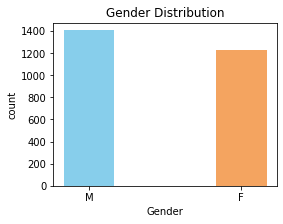

In [23]:
gender_counts = players['gender'].value_counts()

plt.figure(figsize=(4, 3))

distance = [0, 0.15]
plt.bar(
    distance,
    gender_counts.values,
    color=['skyblue', 'sandybrown'],
    width=0.05
)

plt.xticks(distance, gender_counts.index)
plt.xlabel('Gender')
plt.ylabel('count')
plt.title('Gender Distribution')
plt.show()

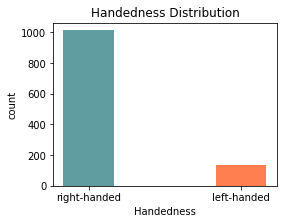

In [24]:
handedness_counts = players['plays'].value_counts()

plt.figure(figsize=(4, 3))

distance = [0, 0.15]
plt.bar(
    distance,
    handedness_counts.values,
    color=['cadetblue', 'coral'],
    width=0.05
)

plt.xticks(distance, handedness_counts.index)
plt.xlabel('Handedness')
plt.ylabel('count')
plt.title('Handedness Distribution')
plt.show()

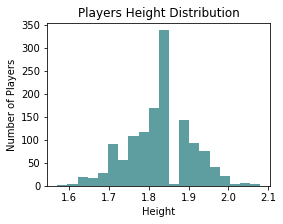

In [25]:
players_heights = players['height'].dropna()
plt.figure(figsize=(4, 3))

plt.hist(
    players_heights,
    bins=20,
    color='cadetblue'
)

plt.xlabel('Height')
plt.ylabel('Number of Players')
plt.title('Players Height Distribution')

plt.show()

In [26]:
top_3_winners_data = winner_counter.most_common(3)

top_3_names = []
top_3_wins = []
top_3_ids = []

for winner_id, num_of_win in top_3_winners_data:
    top_3_ids.append(winner_id)
    top_3_wins.append(num_of_win)
    try:
        winner_name = players.loc[
            players['player_id'] == winner_id, 'full_name'
        ].iloc[0]
        top_3_names.append(winner_name)
    except IndexError:
        top_3_names.append(f"Unknown Player (ID: {winner_id})")

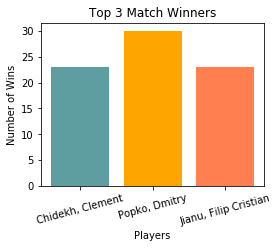

In [27]:
plt.figure(figsize=(4, 3))

names_order = [top_3_names[1], top_3_names[0], top_3_names[2]]
values_order = [top_3_wins[1], top_3_wins[0], top_3_wins[2]]

plt.bar(
    names_order,
    values_order,
    color=['cadetblue', 'orange', 'coral']
)

plt.xlabel('Players')
plt.ylabel('Number of Wins')
plt.title('Top 3 Match Winners')
plt.xticks(rotation=15)
plt.show()

Tournament Insights

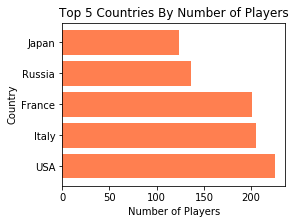

In [34]:
countries_with_most_players = players['country'].value_counts()[:5]

plt.figure(figsize=(4, 3))

plt.barh(
    countries_with_most_players.index,
    countries_with_most_players.values,
    color=['coral']
)

plt.xlabel('Number of Players')
plt.ylabel('Country')
plt.title('Top 5 Countries By Number of Players')
plt.show()

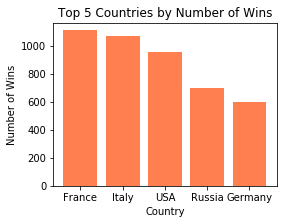

In [29]:
top_5_wins = winner_country_counter.most_common(5)

countries = [country for country, wins in top_5_wins]
wins = [wins for country, wins in top_5_wins]

plt.figure(figsize=(4, 3))

plt.bar(
    countries,
    wins,
    color=['coral']
) 
plt.title('Top 5 Countries by Number of Wins')
plt.xlabel('Country')
plt.ylabel('Number of Wins')

plt.show()

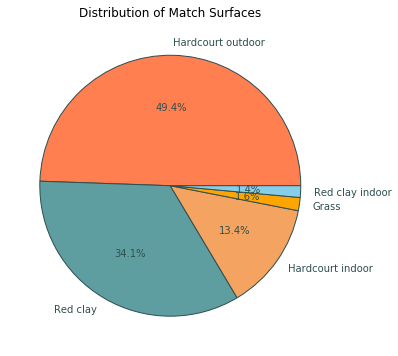

In [30]:
top5_ground_types = tournament_df['ground_type'].value_counts().head()

plt.figure(figsize=(8, 6))

plt.pie(
    top5_ground_types,
    labels= top5_ground_types.index,
    autopct='%1.1f%%',
    colors=['coral', 'cadetblue', 'sandybrown', 'orange', 'skyblue'],
    textprops={'color': 'darkslategray'},
    wedgeprops={'edgecolor': 'darkslategray'}
)

plt.title('Distribution of Match Surfaces')
plt.show()

Matach Dynamics

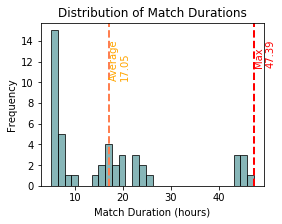

In [31]:
durations = time_merge['duration']/60

max_duration = durations.max()
avg_duration = durations.mean()

plt.figure(figsize=(4, 3))

plt.hist(
    durations,
    bins=30,
    color='cadetblue',
    edgecolor='black',
    alpha=0.75
)

plt.axvline(
    avg_duration,
    color='coral',
    linestyle='--',
    linewidth=2
)
plt.axvline(
    max_duration,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.text(
    avg_duration,
    plt.gca().get_ylim()[1]*0.9,
    f'Average\n{avg_duration:.2f}',
    color='orange',
    rotation=90,
    va='top'
)

plt.text(
    max_duration,
    plt.gca().get_ylim()[1]*0.9,
    f'Max\n{max_duration:.2f}',
    color='red',
    rotation=90,
    va='top'
)

plt.title('Distribution of Match Durations')
plt.xlabel('Match Duration (hours)')
plt.ylabel('Frequency')

plt.show()

Correlations

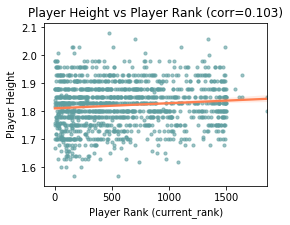

In [32]:
df = players[['height', 'current_rank']].dropna()

height_rank_corr = df['height'].corr(df['current_rank'])

plt.figure(figsize=(4, 3))

sns.regplot(
    data=df,
    x='current_rank',
    y='height',
    scatter_kws={'alpha': 0.6, 's': 10},
    color='cadetblue',
    line_kws={'color': 'coral'}
)

plt.title(f"Player Height vs Player Rank (corr={height_rank_corr:0.3f})")
plt.xlabel("Player Rank (current_rank)")
plt.ylabel("Player Height")

plt.show()

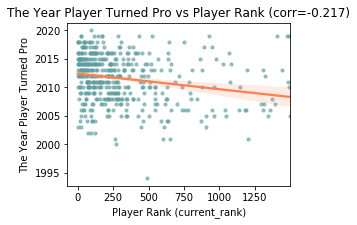

In [33]:
df = players[['turned_pro', 'current_rank']].dropna()

df['turned_pro'] = pd.to_numeric(df['turned_pro'], errors='coerce')

pro_year_rank_corr = df['turned_pro'].corr(df['current_rank'])

plt.figure(figsize=(4, 3))

sns.regplot(
    data=df,
    x='current_rank',
    y='turned_pro',
    scatter_kws={'alpha': 0.6, 's': 10},
    color='cadetblue',
    line_kws={'color': 'coral'}
)

plt.title(f"The Year Player Turned Pro vs Player Rank (corr={pro_year_rank_corr:0.3f})")
plt.xlabel("Player Rank (current_rank)")
plt.ylabel("The Year Player Turned Pro")

plt.show()